In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import pandas as pd
import glob

In [2]:
models=['ACCESS-CM2','ACCESS-ESM1-5','BCC-CSM2-MR','CAS-ESM2-0','CMCC-CM2-SR5','CanESM5','FGOALS-g3','GFDL-ESM4','IPSL-CM6A-LR','KACE-1-0-G','MPI-ESM1-2-HR','MPI-ESM1-2-LR','NESM3']
#13个模式

In [3]:
def cal_cl2llc(ds,num):
    #ds为timexlevxlatxlon的云量数据
    cl=ds['cl'].loc['2015-01-01':'2099-12-30',:,:,:]
    if num in [0,1,9]:#m
        low_cloud = cl.sel(lev= cl.lev<=2000)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="lev")  
    elif num in [2,4,5,6,7,10,11,12]:#p 0-1
        low_cloud = cl.sel(lev= cl.lev>=0.7)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="lev")   
    elif num in [3]:#p hpa
        low_cloud = cl.sel(lev=cl.lev >= 700)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="lev")*100
    else:#p pa
        low_cloud = cl.sel(presnivs=cl.presnivs >= 70000)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="presnivs")
    return low_cloud_cover

In [3]:
def cal_cl2hlc(ds,num):
    #ds为timexlevxlatxlon的云量数据
    cl=ds['cl'].loc['2015-01-01':'2099-12-30',:,:,:]
    if num in [0,1,9]:#m
        low_cloud = cl.sel(lev= cl.lev>=5000)  # 选择高云层次
        low_cloud_cover = low_cloud.max(dim="lev")  
    elif num in [2,4,5,6,7,10,11,12]:#p 0-1
        low_cloud = cl.sel(lev= cl.lev>=0.5)  # 选择高云层次
        low_cloud_cover = low_cloud.max(dim="lev")   
    elif num in [3]:#p hpa
        low_cloud = cl.sel(lev=cl.lev >= 500)  # 选择高云层次
        low_cloud_cover = low_cloud.max(dim="lev")*100
    else:#p pa
        low_cloud = cl.sel(presnivs=cl.presnivs >= 50000)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="presnivs")
    return low_cloud_cover

In [154]:
# for m in range(len(models)):
#     print(models[m])
#     matched_files = glob.glob(os.path.join('/data04/shiy/temp_data/', f'*{models[m]}_ssp245*'))
#     if 'lev' in xr.open_dataset(matched_files[0])['cl'].coords:
#         print(xr.open_dataset(matched_files[0]).lev)
#     else:
#         print(xr.open_dataset(matched_files[0]).presnivs)
        
#         m[0,1,9]
#         p0-1[2,4,5,6,7,10,11,12]
#         phpa[3]
#         ppa[8]

In [5]:
xr.open_dataset('/data04/shiy/temp_data/cl_Amon_BCC-CSM2-MR_historical_r1i1p1f1_gn_185001-186412.nc')

<xarray.Dataset>
Dimensions:    (time: 180, bnds: 2, lev: 46, lat: 160, lon: 320)
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 1864-12-16 12:00:00
  * lev        (lev) float64 0.9926 0.9751 0.9479 ... 0.004959 0.003251 0.00198
  * lat        (lat) float64 -89.14 -88.03 -86.91 -85.79 ... 86.91 88.03 89.14
  * lon        (lon) float64 0.0 1.125 2.25 3.375 ... 355.5 356.6 357.8 358.9
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    lev_bnds   (lev, bnds) float64 ...
    p0         float64 ...
    a          (lev) float64 ...
    b          (lev) float64 ...
    ps         (time, lat, lon) float32 ...
    a_bnds     (lev, bnds) float64 ...
    b_bnds     (lev, bnds) float64 ...
    lat_bnds   (lat, bnds) float64 ...
    lon_bnds   (lon, bnds) float64 ...
    cl         (time, lev, lat, lon) float32 ...
Attributes: (12/49)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          Standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  2289.0
    comment:                The model integration starts from the piControl e...
    ...                     ...
    title:                  BCC-CSM2-MR output prepared for CMIP6
    tracking_id:            hdl:21.14100/e2695f65-b6fb-4347-9afc-577812c1e1b8
    variable_id:            cl
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by BCC is licensed unde...
    cmor_version:           3.3.2

In [5]:
#ssp245实验全球平均的低云llc_gm
olat=np.arange(-89.5,90,1)
olon=np.arange(0.5,360,1)
weights = xr.DataArray(np.cos(np.deg2rad(olat)),dims=['lat'],coords=[olat])
llc_gm=np.zeros((1020,len(models)))
for m in range(len(models)):
    print(models[m])
    matched_files = glob.glob(os.path.join('/data04/shiy/temp_data/', f'*{models[m]}_ssp245*'))
    if len(matched_files)>1:
        ds = xr.open_mfdataset(matched_files,combine='by_coords',parallel=True,chunks={"time": 100})
        llc = cal_cl2llc(ds,m).interp(lon=olon,lat=olat,method='linear',kwargs={'fill_value': 'extrapolate'})
        llc_gm[:,m]=llc.weighted(weights).mean(('lat','lon'))
    else:
        ds = xr.open_dataset(matched_files[0])
        llc = cal_cl2llc(ds,m).interp(lon=olon,lat=olat,method='linear',kwargs={'fill_value': 'extrapolate'})
        llc_gm[:,m]=llc.weighted(weights).mean(('lat','lon'))
# print(llc)

ACCESS-CM2
ACCESS-ESM1-5
BCC-CSM2-MR
CAS-ESM2-0
CMCC-CM2-SR5
CanESM5
FGOALS-g3
GFDL-ESM4
IPSL-CM6A-LR
KACE-1-0-G
MPI-ESM1-2-HR
MPI-ESM1-2-LR
NESM3


In [13]:
xr.open_dataset('/data04/shiy/temp_data/cl_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_224101-226012.nc').time

<xarray.DataArray 'time' (time: 240)>
array(['2241-01-16T12:00:00.000000000', '2241-02-15T00:00:00.000000000',
       '2241-03-16T12:00:00.000000000', ..., '2260-10-16T12:00:00.000000000',
       '2260-11-16T00:00:00.000000000', '2260-12-16T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2241-01-16T12:00:00 ... 2260-12-16T12:00:00
Attributes:
    bounds:         time_bnds
    axis:           T
    long_name:      time
    standard_name:  time

In [47]:
def cal_cl2llc_ssp55(ds,num):
    #ds为timexlevxlatxlon的云量数据
    tl=len(ds.time)
    time=pd.date_range('20150101',periods=tl,freq='M')
    ds['time']=time
    cl=ds['cl'].loc['2015-01-01':'2100-01-01',:,:,:]
    if num in [0,1,9]:#m
        low_cloud = cl.sel(lev= cl.lev<=2000)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="lev")  
    elif num in [2,4,5,6,7,10,11,12]:#p 0-1
        low_cloud = cl.sel(lev= cl.lev>=0.7)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="lev")   
    elif num in [3]:#p hpa
        low_cloud = cl.sel(lev=cl.lev >= 700)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="lev")*100
    else:#p pa
        low_cloud = cl.sel(presnivs=cl.presnivs >= 70000)  # 选择低云层次
        low_cloud_cover = low_cloud.max(dim="presnivs")
    return low_cloud_cover

In [49]:
llc_gm_585=np.zeros((1020,len(models)))
for m in range(len(models)):
    print(models[m])
    matched_files = glob.glob(os.path.join('/data04/shiy/temp_data/', f'*{models[m]}_ssp585*'))
    if m==0:
        print('discard')
    elif m==1:
        ds = xr.open_mfdataset(matched_files[0:5],combine='by_coords',parallel=True,chunks={"time": 100},use_cftime=True)
        llc = cal_cl2llc_ssp55(ds,m).interp(lon=olon,lat=olat,method='linear',kwargs={'fill_value': 'extrapolate'})
        llc_gm_585[:,m]=llc.weighted(weights).mean(('lat','lon'))
    elif m!=0 and m!=1 and len(matched_files)>1:
        ds = xr.open_mfdataset(matched_files,combine='by_coords',parallel=True,chunks={"time": 100},use_cftime=True)
        llc = cal_cl2llc_ssp55(ds,m).interp(lon=olon,lat=olat,method='linear',kwargs={'fill_value': 'extrapolate'})
        llc_gm_585[:,m]=llc.weighted(weights).mean(('lat','lon'))
    elif len(matched_files)==1:
        ds = xr.open_dataset(matched_files[0])
        llc = cal_cl2llc_ssp55(ds,m).interp(lon=olon,lat=olat,method='linear',kwargs={'fill_value': 'extrapolate'})
        llc_gm_585[:,m]=llc.weighted(weights).mean(('lat','lon'))

ACCESS-CM2
discard
ACCESS-ESM1-5
BCC-CSM2-MR
CAS-ESM2-0
CMCC-CM2-SR5
CanESM5
FGOALS-g3
GFDL-ESM4
IPSL-CM6A-LR
KACE-1-0-G
MPI-ESM1-2-HR
MPI-ESM1-2-LR
NESM3


In [6]:
time=pd.date_range('20150101','20991231',freq='M')
llc_gm=xr.DataArray(llc_gm,dims=['time','models'],coords=[time,models])

In [51]:
time=pd.date_range('20150101','20991231',freq='M')
llc_gm_585=xr.DataArray(llc_gm_585,dims=['time','models'],coords=[time,models])

In [57]:
llc_gm.groupby('time.year').mean().to_netcdf('./ssp245_2015-2100_yearly_13model.nc')
llc_gm_585.groupby('time.year').mean().to_netcdf('./ssp585_2015-2100_yearly_13model.nc')

In [60]:
models=['ACCESS-CM2','ACCESS-ESM1-5','AWI-CM-1-1-MR','BCC-CSM2-MR','CanESM5','CAS-ESM2-0','CESM2-WACCM','CIESM','CMCC-CM2-SR5','E3SM-1-0','EC-Earth3-CC','FGOALS-f3-L','FGOALS-g3','GFDL-ESM4','INM-CM4-8','INM-CM5-0','IPSL-CM6A-LR','KACE-1-0-G','KIOST-ESM','MIROC6','MPI-ESM1-2-HR','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3']
len(models)

24

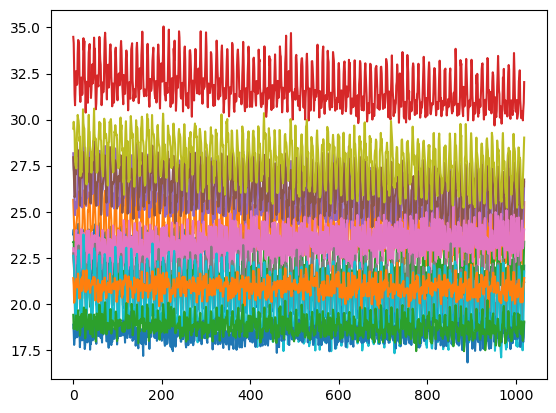

In [9]:
plt.plot(llc_gm)

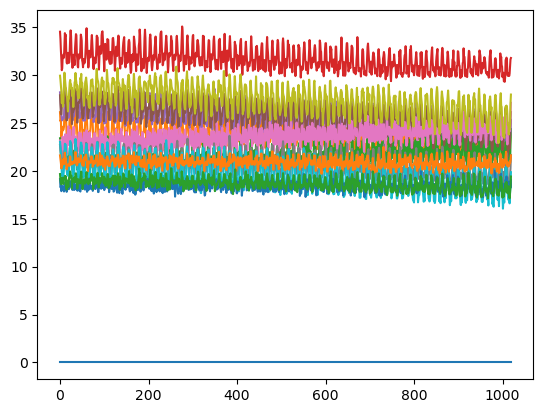

In [50]:
plt.plot(llc_gm_585)

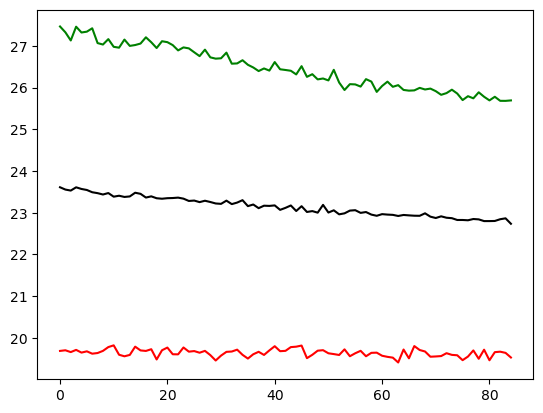

In [10]:
plt.plot(llc_gm.groupby('time.year').mean().mean('models'),'k')
plt.plot(llc_gm.groupby('time.year').mean().loc[:,['MPI-ESM1-2-HR','MPI-ESM1-2-LR']].mean('models'),'r')
plt.plot(llc_gm.groupby('time.year').mean().loc[:,['CAS-ESM2-0','ACCESS-CM2']].mean('models'),'g')

In [54]:
models

['ACCESS-CM2',
 'ACCESS-ESM1-5',
 'BCC-CSM2-MR',
 'CAS-ESM2-0',
 'CMCC-CM2-SR5',
 'CanESM5',
 'FGOALS-g3',
 'GFDL-ESM4',
 'IPSL-CM6A-LR',
 'KACE-1-0-G',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NESM3']

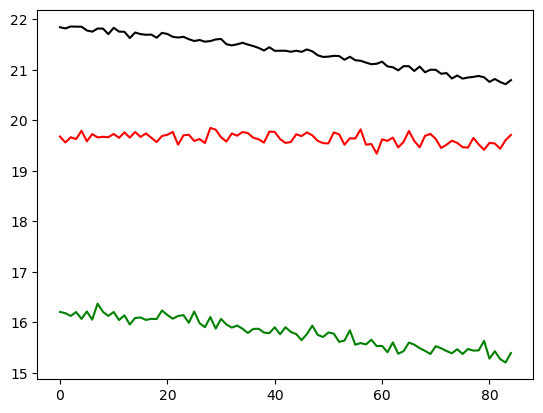

In [53]:
plt.plot(llc_gm_585.groupby('time.year').mean().mean('models'),'k')
plt.plot(llc_gm_585.groupby('time.year').mean().loc[:,['MPI-ESM1-2-HR','MPI-ESM1-2-LR']].mean('models'),'r')
plt.plot(llc_gm_585.groupby('time.year').mean().loc[:,['CAS-ESM2-0','ACCESS-CM2']].mean('models'),'g')

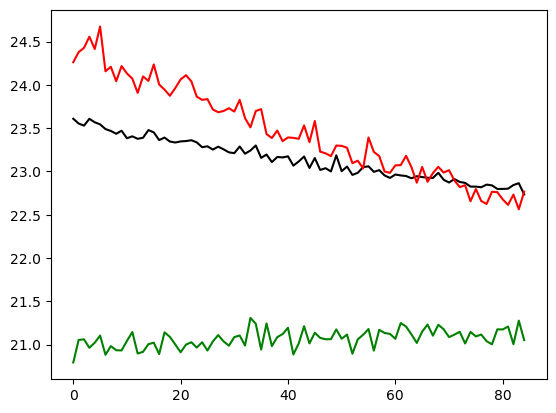

In [193]:
plt.plot(llc_gm.groupby('time.year').mean().mean('models'),'k')
plt.plot(llc_gm.groupby('time.year').mean().loc[:,['CMCC-CM2-SR5','ACCESS-CM2']].mean('models'),'r')
plt.plot(llc_gm.groupby('time.year').mean().loc[:,['NESM3','FGOALS-g3']].mean('models'),'g')

In [61]:
models=['ACCESS-CM2','ACCESS-ESM1-5','BCC-CSM2-MR','CanESM5','CAS-ESM2-0','CESM2-WACCM','CMCC-CM2-SR5','EC-Earth3-CC','FGOALS-g3','GFDL-ESM4','INM-CM4-8','INM-CM5-0','IPSL-CM6A-LR','KACE-1-0-G','KIOST-ESM','MIROC6','MPI-ESM1-2-HR','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3']

len(models)

20